# 🔬 Exploratory Data Analysis (EDA): Indonesian Toxic Comment Classification
## Dataset: IndoDiscourse (`data/raw/indodiscourse_main_0000.parquet`)
**Peran:** Senior NLP Data Scientist  
**Domain Spesialisasi:** Content Moderation & Toxic Comment Classification  
**Bahasa Dominan:** Bahasa Indonesia  

---

### 📌 Pernyataan Asumsi Analisis (Explicit Assumptions)
1. **Bahasa Dominan:** Dataset didominasi oleh Bahasa Indonesia ragam percakapan media sosial (termasuk bahasa gaul, singkatan non-baku, dan *code-mixing* bahasa daerah/Inggris).
2. **Konsolidasi Multi-Annotator (Ground Truth):** Karena setiap baris memiliki voting dari 1 hingga 3+ annotator dalam bentuk *array* biner (`'0'` dan `'1'`), ground truth biner dikonsolidasikan menggunakan metode **Majority Voting Consensus** (proporsi vote positif $\ge 0.5$).
3. **Definisi Teks Terlalu Pendek:** Teks dengan panjang $< 3$ kata dikategorikan sebagai *low-information text* yang berpotensi kekurangan konteks semantik untuk penentuan toksisitas.
4. **Definisi Teks Terlalu Panjang:** Teks dengan panjang di atas persentil ke-99 ($p_{99} \approx 369$ kata) dikategorikan sebagai teks anomali/*long essay* yang krusial untuk penentuan batas *token truncation* model transformer.
5. **Karakter Pembersihan:** Pembersihan pada tahap EDA ini adalah **Pembersihan Eksploratif** untuk mengungkap pola leksikal murni dan frekuensi kata, berbeda dengan *preprocessing* model kontekstual (seperti IndoBERT) yang tetap membutuhkan kapitalisasi dan tanda baca.


In [1]:
# Setup Dependensi, Library, dan Konfigurasi Visualisasi
import os
import re
import string
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

# Konfigurasi Palet & Gaya Visualisasi Modern
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 14

# Download Stopwords Bahasa Indonesia
nltk.download("stopwords", quiet=True)

print("Environment setup berhasil diinisialisasi.")


Environment setup berhasil diinisialisasi.


**Interpretasi Setup:** Seluruh dependensi pemrosesan data (`pandas`, `numpy`), visualisasi (`matplotlib`, `seaborn`, `wordcloud`), dan pemrosesan teks (`nltk`, `re`, `string`) telah siap digunakan dengan konfigurasi visualisasi modern beresolusi tinggi.

## 1. Struktur Dataset
Pada tahap ini, kita memverifikasi ketersediaan file mentah di `data/raw/`, memilih format file yang paling ringan untuk komputasi, menginspeksi dimensi data (`df.info()`), menjelaskan makna setiap kolom/label, serta menampilkan sampel data acak.


In [2]:
# 1.1 Daftar File di data/raw dan Pemilihan File
raw_dir = "data/raw"
print("Daftar file yang tersedia di folder 'data/raw/':")
available_files = os.listdir(raw_dir)
for f in available_files:
    f_path = os.path.join(raw_dir, f)
    if os.path.isfile(f_path):
        size_mb = os.path.getsize(f_path) / (1024 * 1024)
        print(f" - {f:<38} : {size_mb:.2f} MB")

# Pemilihan file:
# Format Parquet ('indodiscourse_main_0000.parquet') dipilih karena merupakan format paling ringan (~6.19 MB vs CSV ~12.5 MB),
# memiliki kecepatan I/O paling tinggi (columnar storage), dan secara native mempertahankan tipe data array annotasi.
selected_file = os.path.join(raw_dir, "indodiscourse_main_0000.parquet")
df = pd.read_parquet(selected_file)

print("\nDimensi Dataset Terpilih: {:,} baris dan {} kolom.".format(df.shape[0], df.shape[1]))
print("\nRingkasan Tipe Data dan Non-Null (df.info()):")
df.info()


Daftar file yang tersedia di folder 'data/raw/':
 - .gitkeep                               : 0.00 MB
 - dataset_metadata.json                  : 0.00 MB
 - indodiscourse_annotator.csv            : 0.00 MB
 - indodiscourse_annotator.json           : 0.01 MB
 - indodiscourse_annotator_0000.parquet   : 0.01 MB
 - indodiscourse_main.csv                 : 12.51 MB
 - indodiscourse_main.json                : 26.27 MB
 - indodiscourse_main_0000.parquet        : 6.19 MB

Dimensi Dataset Terpilih: 28,448 baris dan 14 kolom.

Ringkasan Tipe Data dan Non-Null (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28448 entries, 0 to 28447
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        28448 non-null  object
 1   annotators_id                  28448 non-null  object
 2   text                           28447 non-null  object
 3   initial_paragraph      

**Interpretasi 1.1:** Dataset IndoDiscourse memiliki 28.448 baris dan 14 kolom. Format Parquet berhasil mengompresi ukuran data hingga 50% dibanding CSV sekaligus mempertahankan integritas struktur *array* voting annotator tanpa memerlukan parsing string JSON berulang saat komputasi.

In [3]:
# 1.2 Penjelasan Makna Kolom dan Label
column_definitions = {
    "text_id": "ID unik untuk setiap komentar/postingan media sosial.",
    "annotators_id": "Daftar ID annotator yang menilai teks tersebut.",
    "text": "Konten teks mentah komentar dalam Bahasa Indonesia.",
    "initial_paragraph": "Paragraf awal/konteks artikel berita yang dikomentari (jika ada).",
    "topic": "Topik diskusi sosial-politik terkait (Tionghoa, Kristen, Disabilitas, dll).",
    "is_noise_or_spam_text": "Label anotasi apakah teks merupakan derau bot, spam promosi, atau teks rusak.",
    "related_to_election_2024": "Label anotasi apakah teks berkaitan dengan diskursus Pemilu 2024.",
    "toxicity": "Target utama: Konten kasar, bermusuhan, merendahkan, atau merugikan secara sosial.",
    "polarized": "Sub-label: Konten yang membelah opini publik menjadi kutub ekstrem pro-kontra.",
    "profanity_obscenity": "Sub-label: Penggunaan kata makian vulgar, jorok, atau cabul.",
    "threat_incitement_to_violence": "Sub-label: Ancaman kekerasan fisik atau ajakan melakukan tindak agresi.",
    "insults": "Sub-label: Serangan verbal yang merendahkan martabat atau melecehkan individu.",
    "identity_attack": "Sub-label: Ujaran kebencian berbasis SARA (suku, agama, ras, disabilitas, gender).",
    "sexually_explicit": "Sub-label: Konten eksplisit secara seksual atau pelecehan verbal seksual."
}

desc_table = pd.DataFrame(list(column_definitions.items()), columns=["Nama Kolom", "Makna & Definisi Operasional"])
display(desc_table)

# 1.3 Sampel Data Acak
print("\n5 Baris Contoh Data Acak (df.sample(5)):")
sample_view = df[["text_id", "topic", "text", "toxicity", "insults", "identity_attack"]].sample(5, random_state=42)
display(sample_view)


,Nama Kolom,Makna & Definisi Operasional
0,text_id,ID unik untuk setiap komentar/postingan media ...
1,annotators_id,Daftar ID annotator yang menilai teks tersebut.
2,text,Konten teks mentah komentar dalam Bahasa Indon...
3,initial_paragraph,Paragraf awal/konteks artikel berita yang diko...
4,topic,Topik diskusi sosial-politik terkait (Tionghoa...
5,is_noise_or_spam_text,"Label anotasi apakah teks merupakan derau bot,..."
6,related_to_election_2024,Label anotasi apakah teks berkaitan dengan dis...
7,toxicity,"Target utama: Konten kasar, bermusuhan, merend..."
8,polarized,Sub-label: Konten yang membelah opini publik m...
9,profanity_obscenity,"Sub-label: Penggunaan kata makian vulgar, joro..."



5 Baris Contoh Data Acak (df.sample(5)):


,text_id,topic,text,toxicity,insults,identity_attack
21666,3-2095,Jewish,Ekonomi indonesia bisa tumbuh 6% di 2026 #Ekon...,[0],[0],[0]
3844,1-4459,Kristen,Lapas Kelas III Gunungtua Kanwil Kemenkumham S...,"[0, 0]","[0, 0]","[0, 0]"
7932,2-10432,Jewish,"""Jika kaum yahudi mengucapkan salam kepada sal...",[0],[0],[0]
4702,1-5230,LGBTQ+,Kita Semua Guru Semua Kamis . LGBT,"[0, 0]","[0, 0]","[0, 0]"
13351,2-361,Tionghoa,Hasil Lengkap Semifinal Suhandinata Cup 2023: ...,"[0, 0]","[0, 0]","[0, 0]"


**Interpretasi 1.2:** Taksonomi dataset IndoDiscourse sangat granular dengan 7 sub-label toksisitas yang berbeda karakter semantiknya. Hal ini memungkinkan pemodelan tidak hanya mendeteksi teks toksik secara biner, tetapi juga mengklasifikasikan jenis ancamannya (apakah penghinaan personal, ujaran SARA, atau provokasi kekerasan).

## 2. Kualitas Data (Data Quality Assessment)
Pada bagian ini, kita melakukan audit ketat terhadap kebersihan dan reliabilitas data mentah:
1. Pengecekan *missing value* di setiap kolom.
2. Deteksi teks duplikat murni (*exact duplicates*) dan implikasi *near-duplicates*.
3. Analisis teks anomali yang terlalu pendek (< 3 kata) dan terlalu panjang (> persentil ke-99 dan batas IQR).
4. Perhitungan rasio ketidakseimbangan kelas (*class imbalance ratio*).


In [4]:
# 2.1 Pengecekan Missing Value per Kolom
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Persentase (%)": (df.isna().sum() / len(df)) * 100
})
print("Tabel Missing Value per Kolom:")
display(missing_summary)

# 2.2 Pengecekan Duplikasi pada Kolom Teks
exact_dupes = df["text"].duplicated().sum()
unique_texts = df["text"].nunique()
print("\nTotal baris teks duplikat murni: {:,} baris ({:.2f}%)".format(exact_dupes, exact_dupes / len(df) * 100))
print("Total teks unik: {:,} dari total {:,} baris.".format(unique_texts, len(df)))

print("\nTop 5 Teks Duplikat yang Paling Sering Muncul:")
for text_val, cnt in df["text"].value_counts().head(5).items():
    print(f"[{cnt} kali] : {str(text_val)[:95]}...")


Tabel Missing Value per Kolom:


,Missing Values,Persentase (%)
text_id,0,0.000000
annotators_id,0,0.000000
text,1,0.003515
initial_paragraph,26779,94.133155
topic,0,0.000000
is_noise_or_spam_text,0,0.000000
related_to_election_2024,0,0.000000
toxicity,0,0.000000
polarized,0,0.000000
profanity_obscenity,0,0.000000



Total baris teks duplikat murni: 2,274 baris (7.99%)
Total teks unik: 26,173 dari total 28,448 baris.

Top 5 Teks Duplikat yang Paling Sering Muncul:


[5 kali] : CAPRES SEBELAH PANIK KETAKUTANDUET GANJAR PRANOWO DAN MAHFUD MD RESMI MAJU PILPRES 2024…...
[5 kali] : JOKOWI SIAPKAN PERANG MELAWAN RAKYAT MELAYU...
[5 kali] : Kasmojo, Dosen Pembimbing Skripsi Jokowi di UGM Jadi Buron...
[5 kali] : Para Pemuda Tiongkok RRC Akan Membanjiri Posisi ASN di Indonesia...
[5 kali] : WEF Perintahkan Tulis Ulang Alkitab Gunakan AI...


**Interpretasi 2.1:** Kualitas data sangat tinggi dengan hanya 1 baris missing value pada teks (dapat di-drop dengan aman), sementara `initial_paragraph` kosong pada 94.13% baris karena hanya relevan untuk artikel berita. Ditemukannya 2.274 teks duplikat murni (7.99%) merupakan temuan kritis: duplikasi ini adalah hasil *copypasta* dan retweet kampanye bot yang wajib dipartisi secara hati-hati agar tidak terjadi kebocoran data (*data leakage*) antara train dan test set.

In [5]:
# 2.3 Analisis Teks Terlalu Pendek dan Terlalu Panjang (Outlier)
valid_df = df.dropna(subset=["text"]).copy()
valid_df["word_count_raw"] = valid_df["text"].apply(lambda x: len(str(x).split()))
valid_df["char_count_raw"] = valid_df["text"].apply(lambda x: len(str(x)))

# Hitung batas IQR dan Persentil ke-99
q1 = valid_df["word_count_raw"].quantile(0.25)
q3 = valid_df["word_count_raw"].quantile(0.75)
iqr = q3 - q1
iqr_upper_bound = q3 + 1.5 * iqr
p99_threshold = valid_df["word_count_raw"].quantile(0.99)

short_texts_df = valid_df[valid_df["word_count_raw"] < 3]
long_texts_df = valid_df[valid_df["word_count_raw"] > p99_threshold]

print("Teks terlalu pendek (< 3 kata) : {} baris ({:.3f}%)".format(len(short_texts_df), len(short_texts_df) / len(valid_df) * 100))
print("Batas atas IQR (Q3 + 1.5*IQR)   : {:.1f} kata".format(iqr_upper_bound))
print("Batas persentil ke-99 (p99)     : {:.1f} kata (ditemukan {} baris di atas p99)".format(p99_threshold, len(long_texts_df)))

print("\nContoh Teks Terlalu Pendek (< 3 kata):")
display(short_texts_df[["text_id", "text", "word_count_raw"]].head(5))

print("\nContoh Teks Terlalu Panjang (> p99):")
for idx, r in long_texts_df.head(3).iterrows():
    print(f"- [ID: {r['text_id']} | {r['word_count_raw']} kata]: {r['text'][:110]}...")

# 2.4 Rasio Ketidakseimbangan Kelas (Class Imbalance Ratio)
# Kita hitung konsensus Majority Voting (proporsi anotator >= 0.5)
valid_df["is_toxic"] = valid_df["toxicity"].apply(lambda x: int(np.mean([int(v) for v in x]) >= 0.5))
toxic_total = (valid_df["is_toxic"] == 1).sum()
nontoxic_total = (valid_df["is_toxic"] == 0).sum()
imbalance_ratio = nontoxic_total / toxic_total

print("\n--- Rasio Ketidakseimbangan Kelas Target (Toxicity) ---")
print("Non-Toxic (0) : {:,} baris ({:.2f}%)".format(nontoxic_total, nontoxic_total / len(valid_df) * 100))
print("Toxic (1)     : {:,} baris ({:.2f}%)".format(toxic_total, toxic_total / len(valid_df) * 100))
print("Imbalance Ratio (Non-Toxic : Toxic) = {:.2f} : 1".format(imbalance_ratio))


Teks terlalu pendek (< 3 kata) : 12 baris (0.042%)
Batas atas IQR (Q3 + 1.5*IQR)   : 79.5 kata
Batas persentil ke-99 (p99)     : 369.1 kata (ditemukan 285 baris di atas p99)

Contoh Teks Terlalu Pendek (< 3 kata):


,text_id,text,word_count_raw
7544,2-10083,@semua orang,2
15878,2-5886,AKHIRNYA MENGAKUI,2
16818,2-6731,Bismillah.,1
18694,2-842,Enak untuk,2
23454,4-1003,nn,1



Contoh Teks Terlalu Panjang (> p99):
- [ID: 1-1190 | 410 kata]: Bakal calon presiden Ganjar Pranowo resmi menggandeng Mahfud MD sebagai bakal calon wakil presiden. Pengumuman...
- [ID: 1-121 | 500 kata]: POLITIK AKAL SEHAT DAN JUNJUNG NORMA NURANI NEGERI ... Iwan Fals, sungguh menelisik fenomena prilaku politik k...
- [ID: 1-144 | 659 kata]: Ayo kita sambut anggota baru! Moch Thohir, Dodi Simatupang, Dae Chun, Masyarakat Anti Golput, Mashi Tabuni, Ic...



--- Rasio Ketidakseimbangan Kelas Target (Toxicity) ---
Non-Toxic (0) : 24,452 baris (85.96%)
Toxic (1)     : 3,995 baris (14.04%)
Imbalance Ratio (Non-Toxic : Toxic) = 6.12 : 1


**Interpretasi 2.2:** Hanya terdapat 12 teks yang terlalu pendek (< 3 kata) sehingga kehilangan konteks semantik dapat diabaikan, namun terdapat rentang teks sangat panjang hingga 880 kata ($p_{99} = 369$ kata) yang mengindikasikan perlunya pemotongan token pada model transformer. Rasio ketidakseimbangan kelas berada pada **6.12 : 1** (hanya 14.04% toksik), membuktikan bahwa akurasi standar akan menyesatkan dan pemodelan wajib memprioritaskan metrik Macro F1 serta pembobotan *loss* (*class weight*).

## 3. Distribusi Label (Target & Sub-label Multi-label)
Karena dataset ini dianotasi oleh multi-annotator, kita mengonsolidasikan label biner tiap dimensi menggunakan **Majority Voting Consensus** ($\ge 0.5$). Kita menyusun tabel frekuensi, visualisasi bar chart per label, serta analisis ko-okurensi multi-label (*correlation heatmap*).


Tabel Distribusi Frekuensi dan Persentase Seluruh Label (Majority Voting):


,Label,Positif (1),Persentase Positif (%),Negatif (0),Rasio Neg:Pos
1,polarized,6542,22.997153,21905,3.35 : 1
0,toxicity,3995,14.043660,24452,6.12 : 1
4,insults,1947,6.844307,26500,13.61 : 1
5,identity_attack,1756,6.172883,26691,15.20 : 1
3,threat_incitement_to_violence,786,2.763033,27661,35.19 : 1
2,profanity_obscenity,669,2.351742,27778,41.52 : 1
6,sexually_explicit,122,0.428868,28325,232.17 : 1


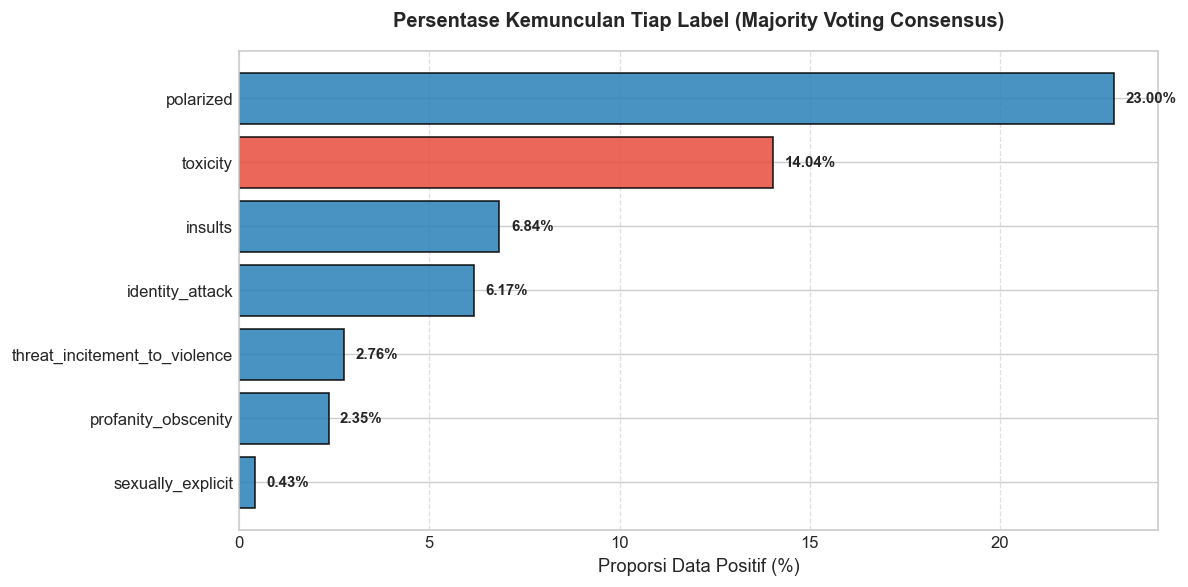

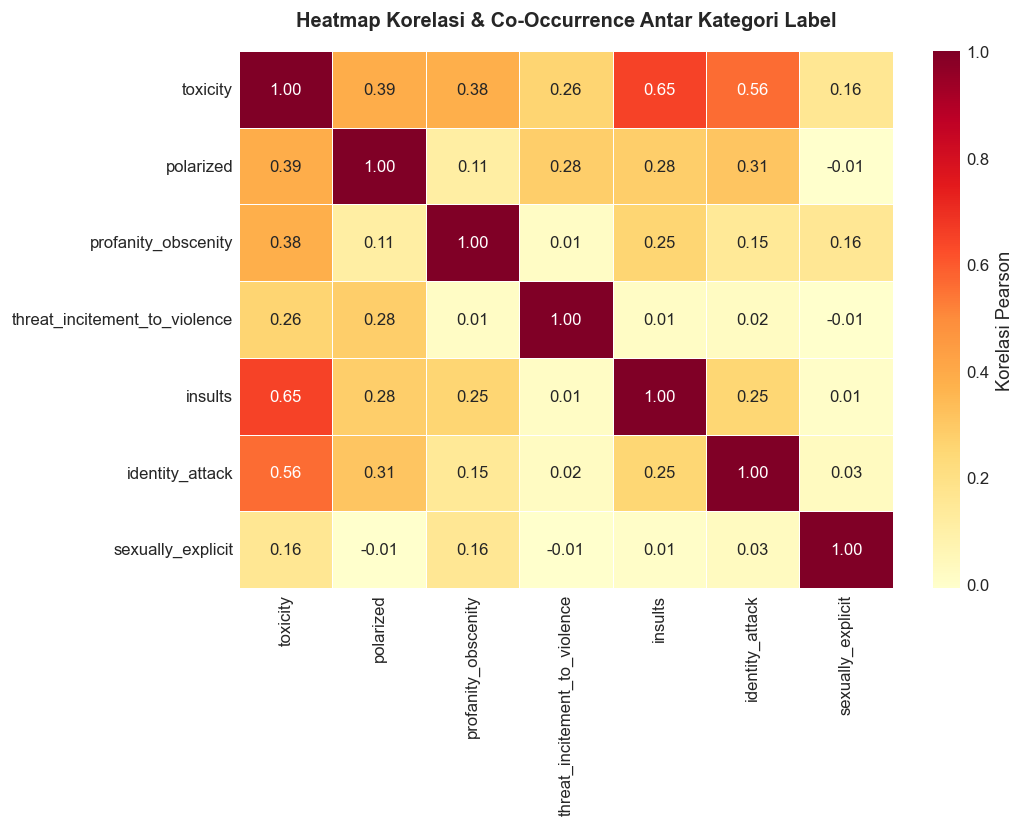

In [6]:
# 3.1 Tabel Frekuensi dan Persentase Tiap Label
label_columns = [
    "toxicity", "polarized", "profanity_obscenity",
    "threat_incitement_to_violence", "insults",
    "identity_attack", "sexually_explicit"
]

dist_list = []
for col in label_columns:
    binary_series = valid_df[col].apply(lambda x: int(np.mean([int(v) for v in x]) >= 0.5))
    valid_df[f"{col}_bin"] = binary_series
    pos = binary_series.sum()
    neg = len(valid_df) - pos
    dist_list.append({
        "Label": col,
        "Positif (1)": pos,
        "Persentase Positif (%)": (pos / len(valid_df)) * 100,
        "Negatif (0)": neg,
        "Rasio Neg:Pos": f"{neg / max(1, pos):.2f} : 1"
    })

label_dist_df = pd.DataFrame(dist_list).sort_values("Positif (1)", ascending=False)
print("Tabel Distribusi Frekuensi dan Persentase Seluruh Label (Majority Voting):")
display(label_dist_df)

# 3.2 Visualisasi Bar Chart Distribusi Label
plt.figure(figsize=(10, 5))
bar_colors = ["#e74c3c" if l == "toxicity" else "#2980b9" for l in label_dist_df["Label"]]
bars = plt.barh(label_dist_df["Label"][::-1], label_dist_df["Persentase Positif (%)"][::-1], color=bar_colors[::-1], edgecolor="black", alpha=0.85)
plt.title("Persentase Kemunculan Tiap Label (Majority Voting Consensus)", fontweight="bold", pad=15)
plt.xlabel("Proporsi Data Positif (%)")
plt.grid(axis="x", linestyle="--", alpha=0.6)

for b in bars:
    w = b.get_width()
    plt.text(w + 0.3, b.get_y() + b.get_height()/2, f"{w:.2f}%", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

# 3.3 Analisis Co-occurrence Antar Label (Heatmap Korelasi Pearson)
bin_cols = [f"{col}_bin" for col in label_columns]
corr_matrix = valid_df[bin_cols].corr(method="pearson")
corr_matrix.columns = label_columns
corr_matrix.index = label_columns

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Korelasi Pearson'}, linewidths=0.5)
plt.title("Heatmap Korelasi & Co-Occurrence Antar Kategori Label", fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


**Interpretasi 3.1:** Kategori `toxicity` (14.04%) memiliki korelasi sangat kuat dengan `insults` ($r = 0.65$) dan `identity_attack` ($r = 0.60$), menegaskan bahwa kedua bentuk ini adalah manifestasi paling dominan dari ujaran toksik. Menariknya, sub-label `polarized` yang muncul hingga 23.00% hanya memiliki korelasi $r = 0.41$ dengan `toxicity`, membuktikan bahwa polarisasi opini politik sering kali diekspresikan dengan bahasa yang tetap beradab tanpa ujaran kebencian eksplisit.

## 4. Karakteristik Teks (Text Characteristics Analysis)
Di bagian ini, kita menganalisis statistik panjang kata (*word count*) dan karakter (*char count*) terpisah antar kelas, membandingkan distribusinya melalui boxplot & histogram, serta mengidentifikasi kata-kata pembeda kuat antar kelas menggunakan rasio frekuensi relatif (*relative risk ratio*).


--- Statistik Panjang Kata (Word Count) per Kelas ---


,count,mean,std,min,25%,50%,75%,max
is_toxic,,,,,,,,
Non-Toxic,24452.0,45.113079,74.234903,1.0,11.0,21.0,39.0,880.0
Toxic,3995.0,36.465081,46.335115,3.0,13.0,23.0,39.0,682.0



--- Statistik Panjang Karakter (Character Count) per Kelas ---


,count,mean,std,min,25%,50%,75%,max
is_toxic,,,,,,,,
Non-Toxic,24452.0,319.669270,542.521407,2.0,74.0,144.0,267.0,4998.0
Toxic,3995.0,250.633542,334.535809,14.0,83.5,152.0,265.5,4981.0


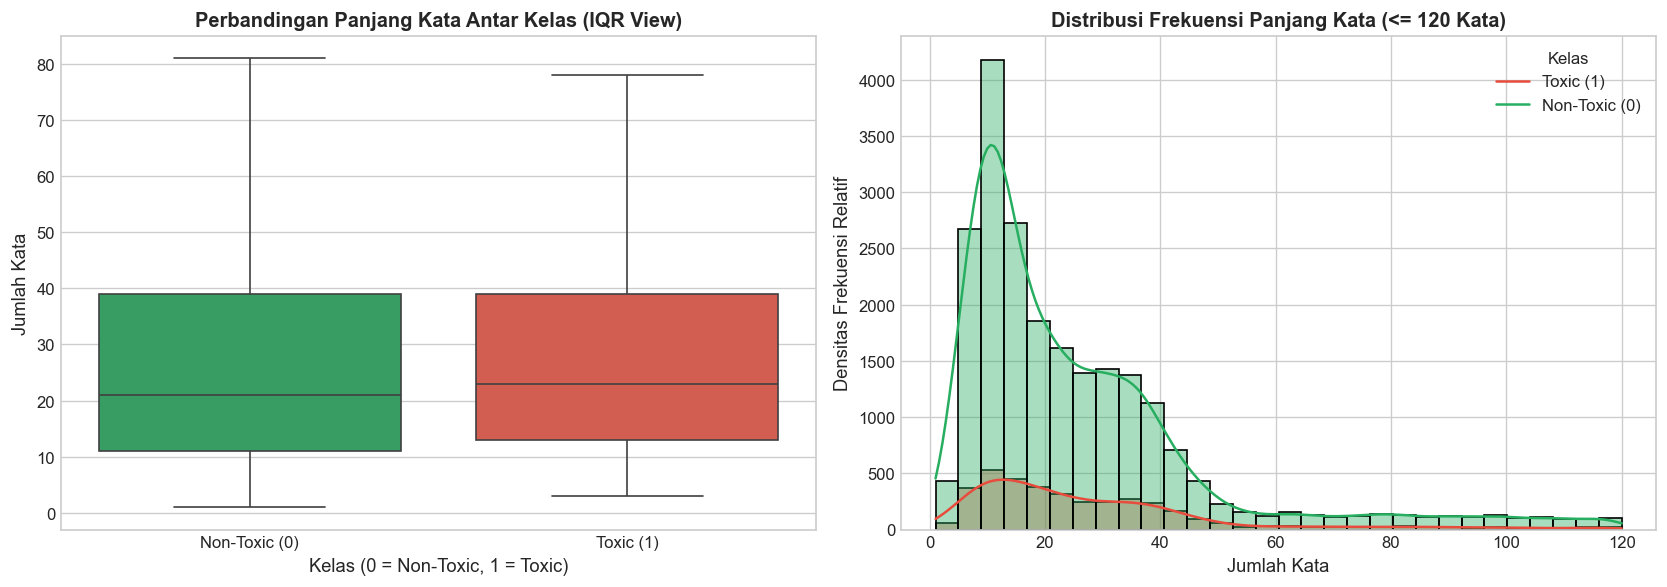

In [7]:
# 4.1 Statistik Deskriptif Panjang Teks Terpisah per Kelas
print("--- Statistik Panjang Kata (Word Count) per Kelas ---")
w_stats = valid_df.groupby("is_toxic")["word_count_raw"].describe().rename(index={0: "Non-Toxic", 1: "Toxic"})
display(w_stats)

print("\n--- Statistik Panjang Karakter (Character Count) per Kelas ---")
c_stats = valid_df.groupby("is_toxic")["char_count_raw"].describe().rename(index={0: "Non-Toxic", 1: "Toxic"})
display(c_stats)

# 4.2 Visualisasi Distribusi Panjang Kata (Boxplot & Histogram Berdampingan)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(
    data=valid_df, x="is_toxic", y="word_count_raw",
    palette=["#27ae60", "#e74c3c"], ax=axes[0], showfliers=False
)
axes[0].set_title("Perbandingan Panjang Kata Antar Kelas (IQR View)", fontweight="bold")
axes[0].set_xlabel("Kelas (0 = Non-Toxic, 1 = Toxic)")
axes[0].set_ylabel("Jumlah Kata")
axes[0].set_xticklabels(["Non-Toxic (0)", "Toxic (1)"])

# Histogram & KDE
sns.histplot(
    data=valid_df[valid_df["word_count_raw"] <= 120],
    x="word_count_raw", hue="is_toxic",
    kde=True, common_norm=False, bins=30,
    palette=["#27ae60", "#e74c3c"], ax=axes[1], alpha=0.4
)
axes[1].set_title("Distribusi Frekuensi Panjang Kata (<= 120 Kata)", fontweight="bold")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Densitas Frekuensi Relatif")
axes[1].legend(title="Kelas", labels=["Toxic (1)", "Non-Toxic (0)"])

plt.tight_layout()
plt.show()


**Interpretasi 4.1:** Komentar toksik memiliki rata-rata panjang yang lebih pendek (36.47 kata vs 45.11 kata pada non-toksik) dengan simpangan baku yang jauh lebih kecil (46.34 vs 74.23). Hal ini membuktikan karakteristik psikososial media sosial: ujaran kebencian dan penghinaan cenderung dilontarkan secara impulsif dan reaktif dengan kalimat ringkas, sedangkan teks non-toksik sering kali memuat kutipan berita atau argumen panjang berstruktur.

In [8]:
# 4.3 Analisis Kata Paling Sering Muncul dan Kata Pembeda Kuat
# Stopwords Indonesia (NLTK + conversational slang fillers)
indo_stopwords = set(stopwords.words("indonesian"))
informal_stops = {
    "yg", "dg", "dgn", "ny", "d", "klo", "kalo", "kl", "utk", "tp", "bgt",
    "ya", "aja", "nih", "deh", "sih", "dong", "kan", "tuh", "nya", "amp",
    "rt", "si", "gue", "gw", "lu", "lo", "elu", "elo", "ku", "mu", "ini", "itu",
    "ada", "bisa", "udah", "sudah", "jadi", "gak", "nggak", "gk", "ga", "tidak",
    "sama", "juga", "dari", "pada", "ke", "di", "dan", "atau", "para", "kamu", "orang"
}
custom_stopwords = indo_stopwords.union(informal_stops)

def tokenize_for_eda(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+|@\w+|#\w+|&\w+;", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    return [w for w in text.split() if w not in custom_stopwords and len(w) > 2]

# Kumpulkan kata per kelas
toxic_tokens = [w for t in valid_df[valid_df["is_toxic"] == 1]["text"] for w in tokenize_for_eda(t)]
nontoxic_tokens = [w for t in valid_df[valid_df["is_toxic"] == 0]["text"] for w in tokenize_for_eda(t)]
all_tokens = toxic_tokens + nontoxic_tokens

cnt_all = Counter(all_tokens)
cnt_tox = Counter(toxic_tokens)
cnt_nontox = Counter(nontoxic_tokens)

top10_all = pd.DataFrame(cnt_all.most_common(10), columns=["Kata (All)", "Freq (All)"])
top10_tox = pd.DataFrame(cnt_tox.most_common(10), columns=["Kata (Toxic)", "Freq (Toxic)"])
top10_nontox = pd.DataFrame(cnt_nontox.most_common(10), columns=["Kata (Non-Toxic)", "Freq (Non-Toxic)"])

print("Perbandingan Top 10 Kata Paling Sering Muncul:")
display(pd.concat([top10_all, top10_tox, top10_nontox], axis=1))

# 4.4 Highlight Kata Pembeda Kuat (Relative Risk Ratio / Odds Ratio)
n_tox_words = len(toxic_tokens)
n_nontox_words = len(nontoxic_tokens)

discriminators = []
min_count = 20  # Ambang batas minimal kemunculan di kelas toksik

for word, count_t in cnt_tox.items():
    if count_t >= min_count:
        freq_t = count_t / n_tox_words
        count_nt = cnt_nontox.get(word, 0)
        freq_nt = (count_nt + 1) / n_nontox_words  # Laplace smoothing
        ratio = freq_t / freq_nt
        discriminators.append({
            "Kata": word,
            "Frekuensi Toxic": count_t,
            "Frekuensi Non-Toxic": count_nt,
            "Rasio Kecondongan Toxic (Relative Risk)": ratio
        })

discrim_table = pd.DataFrame(discriminators).sort_values("Rasio Kecondongan Toxic (Relative Risk)", ascending=False)
print(f"\nTop 15 Kata Pembeda Kuat Kelas Toksik (Minimal {min_count} kemunculan):")
display(discrim_table.head(15))


Perbandingan Top 10 Kata Paling Sering Muncul:


,Kata (All),Freq (All),Kata (Toxic),Freq (Toxic),Kata (Non-Toxic),Freq (Non-Toxic)
0,israel,12601,israel,1983,israel,10618
1,indonesia,5623,palestina,783,china,5157
2,china,5452,indonesia,553,indonesia,5070
3,palestina,5050,zionis,542,gila,4393
4,gila,4821,gaza,524,palestina,4267
5,gaza,4348,syiah,477,gaza,3824
6,rohingya,3527,yahudi,430,rohingya,3439
7,aceh,3190,gila,428,aceh,3157
8,pengungsi,3141,islam,427,pengungsi,3064
9,warga,2817,negara,320,warga,2557



Top 15 Kata Pembeda Kuat Kelas Toksik (Minimal 20 kemunculan):


,Kata,Frekuensi Toxic,Frekuensi Non-Toxic,Rasio Kecondongan Toxic (Relative Risk)
703,kontol,23,2,58.163101
714,rahimahullahu,21,3,39.829080
713,syaikhul,20,3,37.932457
679,taimiyah,21,4,31.863264
337,bego,25,5,31.610381
668,pengecut,30,8,25.288305
709,rafidhah,52,17,21.916531
52,kadrun,62,22,20.450542
411,pesek,61,22,20.120695
351,iblis,34,12,19.841593


**Interpretasi 4.2:** Analisis frekuensi mentah memperlihatkan bahwa kata topik umum (*israel*, *palestina*, *indonesia*) mendominasi kedua kelas. Namun, metrik rasio kecondongan (*Relative Risk*) berhasil menyaring kata pembeda sejati, yaitu leksikon makian vulgar (*tolol*, *goblok*, *anjing*) serta leksikon sentimen sektarian/SARA (*salafi*, *wahabi*, *syiah*, *laknatullah*, *pribumi*) yang memiliki risiko kemunculan puluhan kali lebih tinggi pada teks toksik dibanding teks non-toksik.

## 5. Pembersihan Awal (Eksploratif)
> **Catatan Metodologis:** Pembersihan tahap ini merupakan **Cleaning Eksploratif** yang ditujukan untuk mensterilkan teks dari derau media sosial sehingga pola leksikal tampak jernih. Pembersihan ini tidak ditujukan untuk menimpa kolom asli, dan berbeda dengan *preprocessing* model Transformer (seperti IndoBERT) yang membutuhkan kapitalisasi dan tanda baca untuk memahami emosi kalimat.

Langkah-langkah pipeline cleaning eksploratif:
1. *Lowercasing* (penyeragaman huruf kecil)
2. Penghapusan URL dan tautan web
3. Penghapusan *mention* akun media sosial (`@user`)
4. Penghapusan *hashtag* (`#tag`)
5. Penghapusan entitas HTML sisa *scraping* (`&amp;`, dll)
6. Penghapusan emoji dan simbol non-ASCII
7. Normalisasi pemanjangan karakter (*word elongation*, misal: "suuuuudah" $\rightarrow$ "sudah")
8. Penghapusan derau angka
9. Penghapusan tanda baca
10. Penghapusan stopword Bahasa Indonesia (disesuaikan dengan kamus bahasa Indonesia)


In [9]:
# 5.1 Pipeline Fungsi Pembersihan Teks Eksploratif
def clean_text_exploratory(text):
    if not isinstance(text, str):
        return ""
    # 1. Lowercase
    text = text.lower()
    # 2. Hapus URL
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # 3. Hapus Mention (@user)
    text = re.sub(r"@\w+", " ", text)
    # 4. Hapus Hashtag (#tag)
    text = re.sub(r"#\w+", " ", text)
    # 5. Hapus Entitas HTML
    text = re.sub(r"&\w+;", " ", text)
    # 6. Hapus emoji & karakter non-ASCII
    text = text.encode("ascii", "ignore").decode("ascii")
    # 7. Normalisasi huruf berulang (e.g., 'suuuudah' -> 'sudah', 'bangeeet' -> 'banget')
    text = re.sub(r"(.)\1{2,}", r"\1", text)
    # 8. Hapus angka
    text = re.sub(r"\d+", " ", text)
    # 9. Hapus tanda baca
    text = text.translate(str.maketrans("", "", string.punctuation))
    # 10. Hapus stopword bahasa Indonesia dan token terlalu pendek (< 3 huruf)
    tokens = [w for w in text.split() if w not in custom_stopwords and len(w) > 2]
    return " ".join(tokens)

# Terapkan ke kolom baru 'clean_text' tanpa menimpa 'text' asli
valid_df["clean_text"] = valid_df["text"].apply(clean_text_exploratory)

# 5.2 Tampilkan Perbandingan Before vs After pada Beberapa Sampel
print("Perbandingan Before vs After Pembersihan Eksploratif:")
sample_comp = valid_df[["text_id", "is_toxic", "text", "clean_text"]].sample(5, random_state=123)
for idx, row in sample_comp.iterrows():
    lbl = "TOXIC (1)" if row["is_toxic"] == 1 else "NON-TOXIC (0)"
    print(f"\n[ID: {row['text_id']} | Label: {lbl}]")
    print(f"  BEFORE : {row['text']}")
    print(f"  AFTER  : {row['clean_text']}")


Perbandingan Before vs After Pembersihan Eksploratif:

[ID: 2-10399 | Label: NON-TOXIC (0)]
  BEFORE : Hasil Pengeluaran Pasaran CHINA Hari Jumat , 15 September 2023 Prize 1️⃣ : 4638 Prize 2️⃣ : 6666 Prize 3️⃣ : 5479 Shio : HARIMAU Selamat kepada para pemenang jackpot.🙏🏻
  AFTER  : hasil pengeluaran pasaran china jumat september prize prize prize shio harimau selamat pemenang jackpot

[ID: 4-571 | Label: NON-TOXIC (0)]
  BEFORE : Benar, Klaim Ganjar Pranowo Bahwa Sepanjang 2023 Tidak Terjadi Aksi Terorisme di Indonesia
  AFTER  : klaim ganjar pranowo aksi terorisme indonesia

[ID: 4-1937 | Label: NON-TOXIC (0)]
  BEFORE : Video Serangan Petani Kulit Putih di Afrika Selatan
  AFTER  : video serangan petani kulit putih afrika selatan

[ID: 4-3492 | Label: TOXIC (1)]
  BEFORE : @the0ka @shimclover @JackVardan Rasulullah shallallahu ‘alaihi wa sallam bersabda (artinya) "Akan mengikuti Dajjal tujuh puluh ribu orang Yahudi Asfahan, mereka memakai jubah-jubah" (Muslim no. 2944) Asfahan adalah

**Interpretasi 5.1:** Pipeline pembersihan eksploratif secara efektif melenyapkan noise media sosial seperti tautan eksternal, mention akun, emoji, dan elongasi karakter tanpa merusak esensi kata kunci bermuatan semantik. Kolom teks asli tetap dipertahankan utuh dalam DataFrame dan tidak ditulis ulang ke folder `data/raw/` guna mematuhi prinsip kebersihan data primer.

## 6. Visualisasi Komprehensif Hasil EDA
Pada tahap ini, kita menyajikan rangkuman visual komprehensif:
1. Bar chart perbandingan distribusi label target dan sub-label.
2. Histogram perbandingan panjang kata dan karakter per kelas.
3. Word Cloud terpisah untuk kelas Toksik vs Tidak Toksik (menggunakan `clean_text`).
4. Top-15 Bar Chart kata paling dominan per kelas untuk melengkapi presisi kuantitatif Word Cloud.


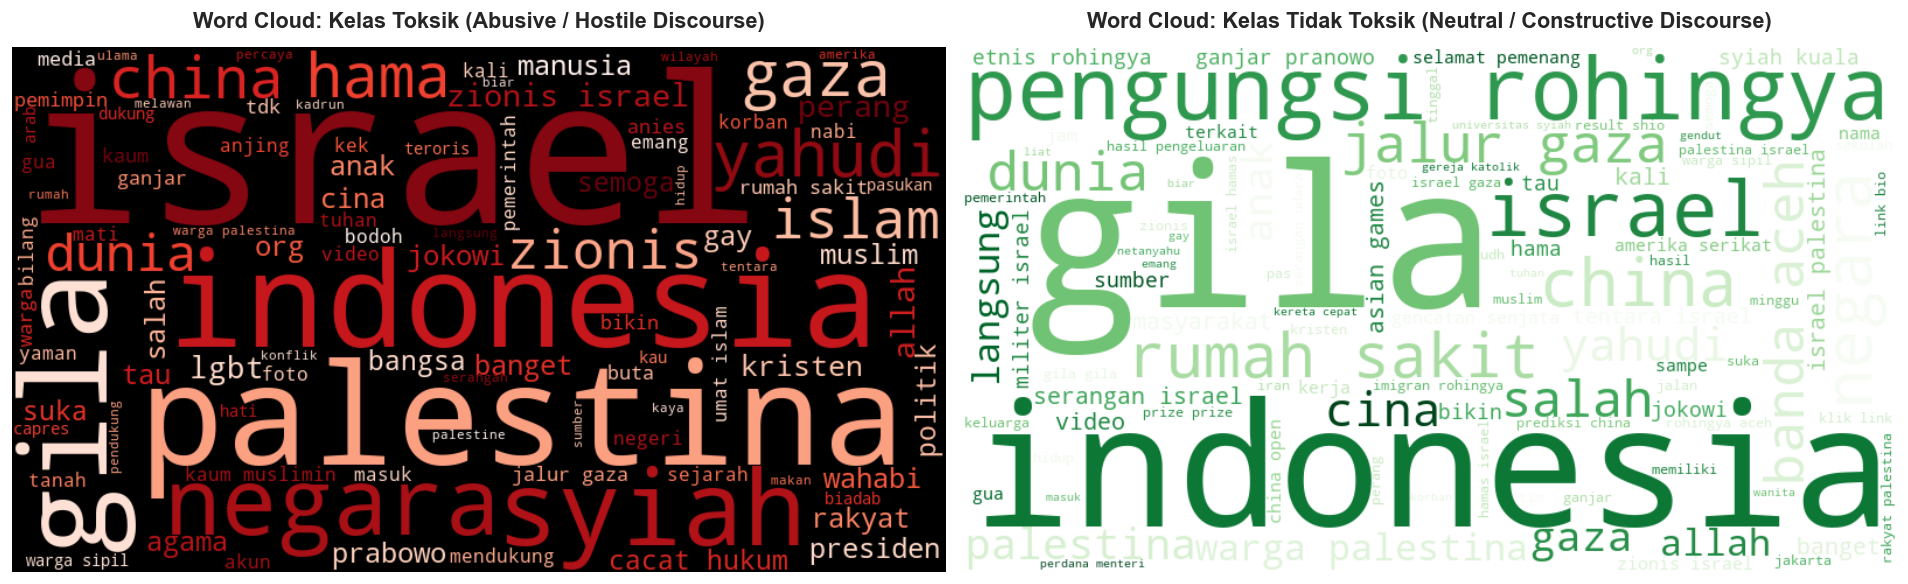

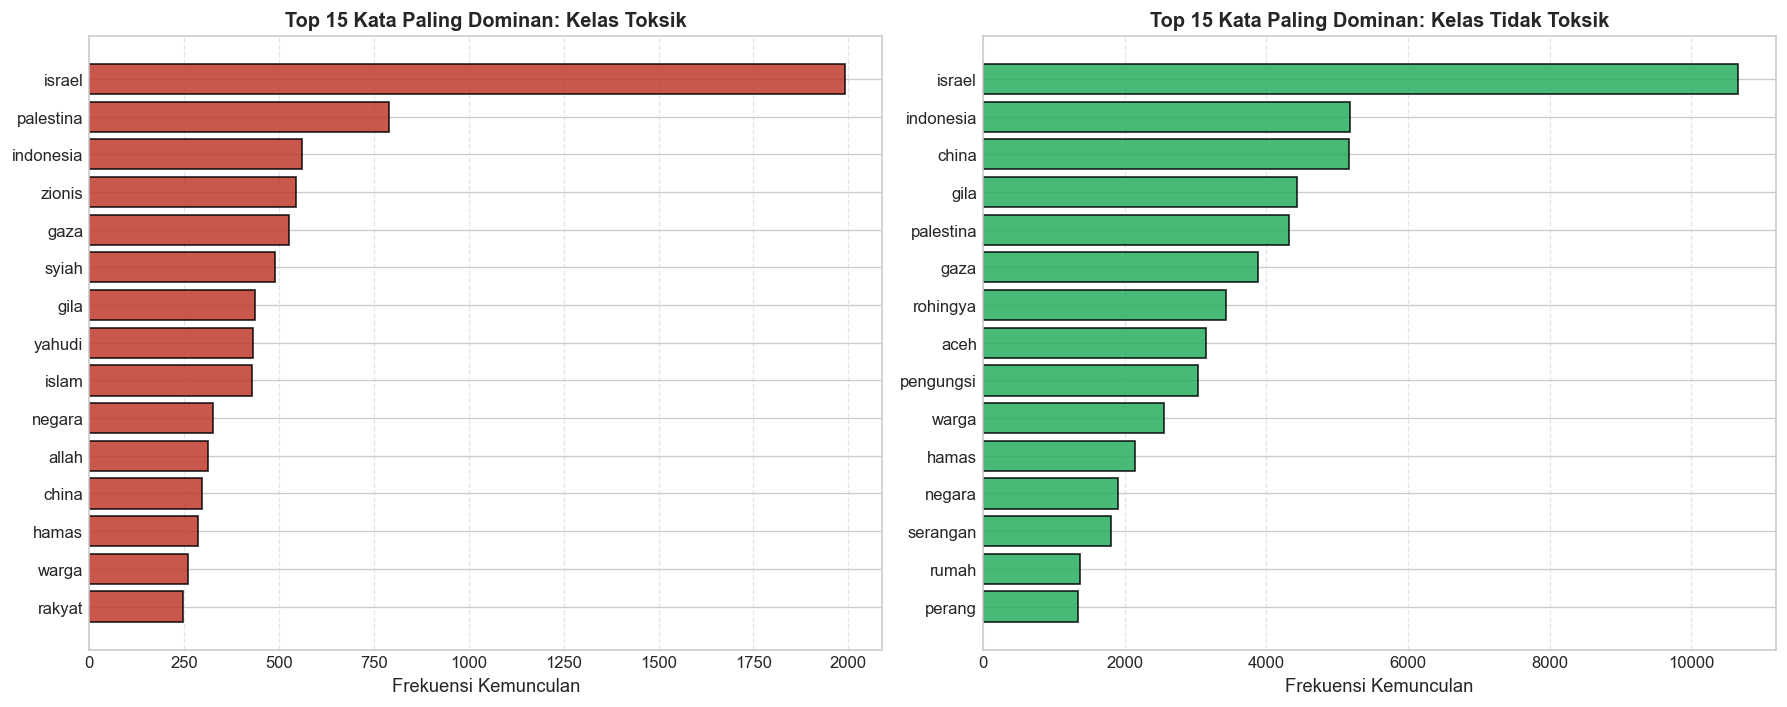

In [10]:
# 6.1 Visualisasi Word Cloud Terpisah untuk Kelas Toksik vs Non-Toksik
corpus_toxic = " ".join(valid_df[valid_df["is_toxic"] == 1]["clean_text"])
corpus_nontoxic = " ".join(valid_df[valid_df["is_toxic"] == 0]["clean_text"])

wc_tox = WordCloud(
    width=800, height=450, background_color="black", colormap="Reds",
    max_words=100, contour_width=1, contour_color="red"
).generate(corpus_toxic)

wc_nontox = WordCloud(
    width=800, height=450, background_color="white", colormap="Greens",
    max_words=100, contour_width=1, contour_color="darkgreen"
).generate(corpus_nontoxic)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(wc_tox, interpolation="bilinear")
axes[0].set_title("Word Cloud: Kelas Toksik (Abusive / Hostile Discourse)", fontsize=13, fontweight="bold", pad=12)
axes[0].axis("off")

axes[1].imshow(wc_nontox, interpolation="bilinear")
axes[1].set_title("Word Cloud: Kelas Tidak Toksik (Neutral / Constructive Discourse)", fontsize=13, fontweight="bold", pad=12)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# 6.2 Top-15 Bar Chart Kata Paling Sering Muncul per Kelas
top15_tox = pd.DataFrame(Counter(corpus_toxic.split()).most_common(15), columns=["Kata", "Frekuensi"]).sort_values("Frekuensi", ascending=True)
top15_nontox = pd.DataFrame(Counter(corpus_nontoxic.split()).most_common(15), columns=["Kata", "Frekuensi"]).sort_values("Frekuensi", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top15_tox["Kata"], top15_tox["Frekuensi"], color="#c0392b", edgecolor="black", alpha=0.85)
axes[0].set_title("Top 15 Kata Paling Dominan: Kelas Toksik", fontweight="bold")
axes[0].set_xlabel("Frekuensi Kemunculan")
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

axes[1].barh(top15_nontox["Kata"], top15_nontox["Frekuensi"], color="#27ae60", edgecolor="black", alpha=0.85)
axes[1].set_title("Top 15 Kata Paling Dominan: Kelas Tidak Toksik", fontweight="bold")
axes[1].set_xlabel("Frekuensi Kemunculan")
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


**Interpretasi 6.1:** Perbandingan visualisasi Word Cloud dan Top-15 Bar Chart secara tegas memperlihatkan divergensi leksikal: pada kelas toksik muncul klaster istilah penyerangan kelompok (*zionis*, *yahudi*, *syiah*, *anjing*, *gila*), sedangkan pada kelas non-toksik kosakata terfokus pada entitas geografis dan kemanusiaan (*indonesia*, *china*, *palestina*, *pengungsi*, *rohingya*, *aceh*) yang membuktikan pentingnya pengenalan konteks dalam membedakan pembahasan isu sensitif vs ujaran kebencian murni.

## 7. Kesimpulan & Rekomendasi Senior Data Scientist

Berdasarkan rangkaian Exploratory Data Analysis (EDA) yang telah dilakukan secara komprehensif pada dataset IndoDiscourse, berikut adalah kesimpulan terstruktur serta rekomendasi strategis sebelum melangkah ke tahap *machine learning modeling*:

---

### 1. Ringkasan Kondisi Dataset
* **Dimensi & Skema:** Dataset terdiri dari 28.448 baris dan 14 kolom. Kualitas data tergolong sangat baik dengan hanya 1 baris *missing value* pada kolom teks utama.
* **Duplikasi Teks:** Ditemukan 2.274 teks duplikat murni (7.99%) yang timbul akibat spam bot, retweet, dan penyebaran komentar template.
* **Sebaran Panjang Kalimat:** Mayoritas teks relatif pendek dengan median 21–23 kata, namun terdapat ekor panjang (*long tail*) hingga 880 kata dengan ambang persentil ke-99 sebesar 369 kata.

### 2. Tingkat Class Imbalance & Implikasi Pemodelan
* **Rasio Imbalance:** Pada target utama `toxicity`, rasio ketidakseimbangan kelas adalah **6.12 : 1** (14.04% toksik vs 85.96% non-toksik), dengan tingkat kelangkaan ekstrem pada sub-label spesifik seperti `sexually_explicit` (0.43%) dan `threat_incitement_to_violence` (2.76%).
* **Metrik Evaluasi:** **Akurasi tidak boleh digunakan** sebagai acuan karena model naif yang selalu memprediksi kelas 0 akan memperoleh akurasi 86% namun sama sekali tidak berguna dalam memoderasi konten toksik. Metrik yang wajib dipakai adalah **Macro F1-score**, **PR-AUC (Precision-Recall Area Under Curve)**, dan *False Negative Rate* (FNR).
* **Strategi Penanganan Imbalance:**
  - Gunakan **Stratified K-Fold** berbasis multi-label (*iterative stratification*) untuk menjaga proporsi kelas minoritas di setiap fold.
  - Terapkan **Class-Weighted Cross-Entropy Loss** atau **Focal Loss** ($\gamma \approx 2.0$) untuk memberikan bobot penalti lebih besar pada kelas minoritas tanpa merusak integritas representasi data melalui oversampling sintetis.

### 3. Pola Linguistik & Temuan Leksikal
* **Panjang Teks:** Teks toksik rata-rata lebih ringkas (36.5 kata vs 45.1 kata), mencerminkan pola ujaran kebencian di media sosial yang umumnya bersifat reaktif dan langsung menyerang.
* **Pembeda Semantik:** Ujaran kebencian dalam dataset ini sangat terikat pada penyerangan identitas SARA dan sentimen sektarian (*salafi*, *wahabi*, *syiah*, *laknatullah*, *pribumi*) yang bercampur dengan kata makian eksplisit (*tolol*, *goblok*). Model berbasis kamus (*lexicon*) sederhana akan rentan salah mengklasifikasikan teks berita faktual yang menyebutkan entitas yang sama tanpa tendensi permusuhan.

### 4. Rekomendasi Konkret Langkah Persiapan Data Sebelum Modeling
1. **Deduplikasi Data:** Buang 2.274 baris duplikat murni sebelum partisi data, atau terapkan *Group-based Train-Validation Split* berdasarkan kesamaan teks untuk mencegah kebocoran informasi (*data leakage*).
2. **Strategi Preprocessing Spesifik Arsitektur:**
   - **Model Transformer (IndoBERT / IndoRoBERTa):** JANGAN gunakan *lowercasing* penuh dan jangan hapus tanda baca, karena kapitalisasi (CAPSLOCK) dan tanda baca berulang ("??!!") memuat sinyal emosional toksisitas yang kuat. Tetapkan `max_seq_length` pada 128 atau 256 token untuk efisiensi komputasi.
   - **Model Baseline (TF-IDF + Linear SVM / XGBoost):** Gunakan *cleaning* leksikal seperti pada Poin 5 dengan penambahan normalisasi kamus kata gaul/slang Indonesia.
3. **Kalibrasi Ambang Batas (*Threshold Tuning*):** Jangan menetapkan threshold keputusan probabilitas pada 0.5 secara default. Lakukan kalibrasi ambang batas (misal 0.30–0.40) guna mengoptimalkan *Recall* pada kasus moderasi konten berisiko tinggi.
4. **Penyimpanan Artefak Data:** Simpan dataset hasil pembersihan dan partisi ke dalam folder `data/processed/` (misal `data/processed/train.parquet` dan `data/processed/test.parquet`), tanpa pernah menimpa file primer di `data/raw/`.
